In [2]:
import pandas as pd
df=pd.read_csv("mall_customers.csv")
print(df.head())
x=df[["Age","Annual_Income_k","spending_score"]]

   customerID  Age  Annual_Income_k  spending_score
0           1   20               28              86
1           2   34               90              73
2           3   60               90              35
3           4   46               20              26
4           5   26               22              60


In [3]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
print(x_scaled[:5])

[[-1.46844688 -0.83089385  1.27598617]
 [-0.31994094  1.38482308  0.81521339]
 [ 1.81299866  1.38482308 -0.5316609 ]
 [ 0.66449272 -1.1167928  -0.85065745]
 [-0.97623005 -1.04531807  0.3544406 ]]


C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


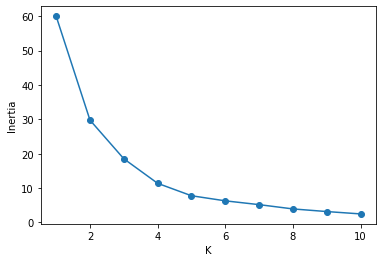

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia=[]
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(x_scaled)
    inertia.append(km.inertia_)
plt.plot(range(1,11),inertia,marker="o")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.show()

In [5]:
kmeans=KMeans(
n_clusters=5,random_state=42,n_init=10
)
kmeans.fit(x_scaled)
df["cluster"]=kmeans.labels_
print(df["cluster"].value_counts())

1    5
3    5
2    4
4    3
0    3
Name: cluster, dtype: int64


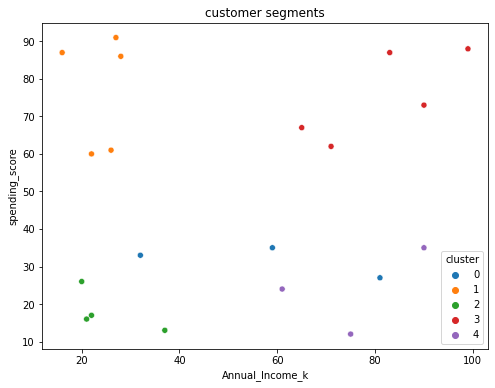

In [6]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
data=df,x="Annual_Income_k",y="spending_score",hue="cluster",palette="tab10"
)
plt.title("customer segments")
plt.show()

In [7]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
print("Explained Variance ratio:",pca.explained_variance_ratio_)

Explained Variance ratio: [0.59651878 0.34454663]


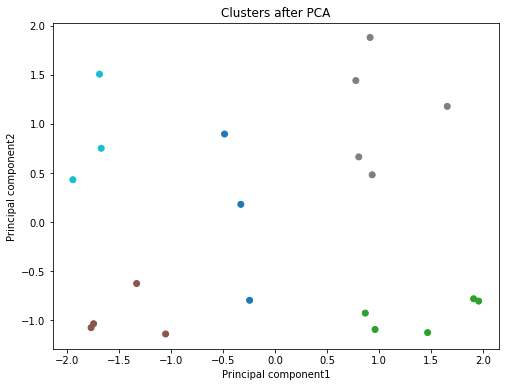

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    x_pca[:,0],x_pca[:,1],
    c=df["cluster"],cmap="tab10"
)
plt.xlabel("Principal component1")
plt.ylabel("Principal component2")
plt.title("Clusters after PCA")
plt.show()